# Phần 1. NumPy trong workflow ML/DL
Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý tensor.

In [1]:
STUDENT_NAME = "Lê Minh Sang"
STUDENT_ID = "25521574"
print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Lê Minh Sang (25521574)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Khong tim thay data/automobile_raw.csv")
print("Data path:", DATA_PATH.resolve())

Data path: D:\STUDY\MLIoT\homework\week2_2\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

- Hàng [2,1,0.1]: shift trừ 2 -> class 0 thắng (~0.659)
- Hàng [1000,1001,999]: shift trừ 1001 -> giống hệt hàng 1, khỏi overflow
- Hàng [-2,-1,3]: shift trừ 3 -> class 2 thắng
- Hàng [0.5,0.5,0.5]: bằng nhau -> mỗi class 1/3, argmax trả về 0

In [ ]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [ ]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [ ]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]
print("correct_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_indices:", review_indices)

correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.fliplr(image_batch_uint8).astype(np.float32).copy()
augmented_batch[0, 0, 0, 0] = 1.0
assert normalized_batch[0, 0, 0, 0] != 1.0
print("Normalized batch shape:", normalized_batch.shape)
print("Augmented batch shape:", augmented_batch.shape)
print(f"normalized[0,0,0,0] = {normalized_batch[0,0,0,0]}")
print(f"augmented[0,0,0,0] = {augmented_batch[0,0,0,0]}")

Normalized batch shape: (2, 4, 4, 3)
Augmented batch shape: (2, 4, 4, 3)
normalized[0,0,0,0] = 0.0
augmented[0,0,0,0] = 1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
---



**1. Mỗi dòng đại diện cho đối tượng gì?**
> Mỗi dòng là một mẫu xe cụ thể trong bộ dữ liệu Auto Imports 1985, bao gồm hãng sản xuất, kiểu dáng, thông số động cơ và giá bán.

**2. Ký hiệu missing value trong CSV là gì?**
> Dấu `?` là ký hiệu missing value, được giữ lại để sinh viên tự xử lý.

**3. `symboling` có ý nghĩa gì?**
> Mức độ đánh giá rủi ro bảo hiểm: giá trị càng cao (3) = xe càng 'rủi ro', càng thấp (-3) = xe càng 'an toàn'.


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
raw_df = pd.read_csv(DATA_PATH, na_values=[])
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()
print(f"Shape: {raw_shape}")
print(f"Missing markers (?): {raw_missing_marker_count}")
print(f"\nDtypes (raw):\n{raw_df.dtypes}")

Shape: (205, 26)
Missing markers (?): 59

Dtypes (raw):
symboling              int64
normalized_losses     object
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                  object
stroke                object
compression_ratio    float64
horsepower            object
peak_rpm              object
city_mpg               int64
highway_mpg            int64
price                 object
dtype: object


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ["symboling", "normalized_losses", "wheel_base", "length", "width", "height",
                  "curb_weight", "engine_size", "bore", "stroke", "compression_ratio",
                  "horsepower", "peak_rpm", "city_mpg", "highway_mpg", "price"]

In [15]:
df_clean = raw_df.replace("?", np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="raise")
missing_by_column = df_clean.isnull().sum()
missing_by_column = missing_by_column[missing_by_column > 0]
print("Missing values by column:")
print(missing_by_column)
print(f"Tong missing: {missing_by_column.sum()}")

Missing values by column:
normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64
Tong missing: 59


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Giải thích:**

**1. Không nên fill tất cả numeric columns bằng cùng giá trị?**
> Mỗi cột có phân bố và ý nghĩa khác nhau. `price` (vài chục ngàn) và `symboling` (-3 đến 3) không thể dùng cùng mean. Fill cùng giá trị sẽ sai lệch phân bố của cột variance cao như `price`.

**2. Với `price`, drop hay fill?**
> **Drop** các dòng thiếu `price`. Vì `price` là biến mục tiêu quan trọng nhất. Fill sẽ tạo điểm dữ liệu giả, làm sai lệch biểu đồ. Chỉ thiếu 4 dòng/205.

**3. `normalized_losses` thiếu nhiều nhất (41 dòng, ~20%).**
> Giới hạn khả năng phân tích mối quan hệ giữa tổn thất bảo hiểm và đặc trưng khác. Vẫn giữ lại (80% có dữ liệu), nhưng kết quả có bias.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ["curb_weight", "engine_size", "horsepower", "city_mpg", "highway_mpg", "price"]

In [17]:
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).copy()
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std
print(f"Shape sau dropna: {analysis_df.shape} (drop {df_clean.shape[0] - analysis_df.shape[0]} dong)")
print(f"X_auto shape: {X_auto.shape}, dtype: {X_auto.dtype}")

Shape sau dropna: (199, 26) (drop 6 dong)
X_auto shape: (199, 6), dtype: float64


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
price_index = AUTO_FEATURES.index("price")
price_values = X_auto[:, price_index]
price_mean = np.mean(price_values)
price_std = np.std(price_values)
price_z = (price_values - price_mean) / price_std
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask].copy()
print(f"So outlier (|z| > 2): {price_outlier_mask.sum()} dong")
print(f"\nCac xe co price outlier:")
print(price_outliers[["make", "body_style", "price"]])

So outlier (|z| > 2): 14 dong

Cac xe co price outlier:
              make   body_style    price
15             bmw        sedan  30760.0
16             bmw        sedan  41315.0
17             bmw        sedan  36880.0
47          jaguar        sedan  32250.0
48          jaguar        sedan  35550.0
49          jaguar        sedan  36000.0
70   mercedes-benz        sedan  31600.0
71   mercedes-benz        sedan  34184.0
72   mercedes-benz  convertible  35056.0
73   mercedes-benz        sedan  40960.0
74   mercedes-benz      hardtop  45400.0
126        porsche      hardtop  32528.0
127        porsche      hardtop  34028.0
128        porsche  convertible  37028.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
engine_sizes = X_auto[:, AUTO_FEATURES.index("engine_size")]
prices = X_auto[:, AUTO_FEATURES.index("price")]
corr_matrix = np.corrcoef(engine_sizes, prices)
engine_price_corr = corr_matrix[0, 1]
price_by_body_style = analysis_df.groupby("body_style")["price"].mean().sort_index()
print(f"Pearson correlation (engine_size vs price): {engine_price_corr:.4f}")
print(f"\nMean price theo body_style:")
print(price_by_body_style.round(0))

Pearson correlation (engine_size vs price): 0.8739

Mean price theo body_style:
body_style
convertible    21890.0
hardtop        22208.0
hatchback       9958.0
sedan          14460.0
wagon          12500.0
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

### M2.1 Phân phối price
**Biểu đồ:** Histogram + KDE của `price`.

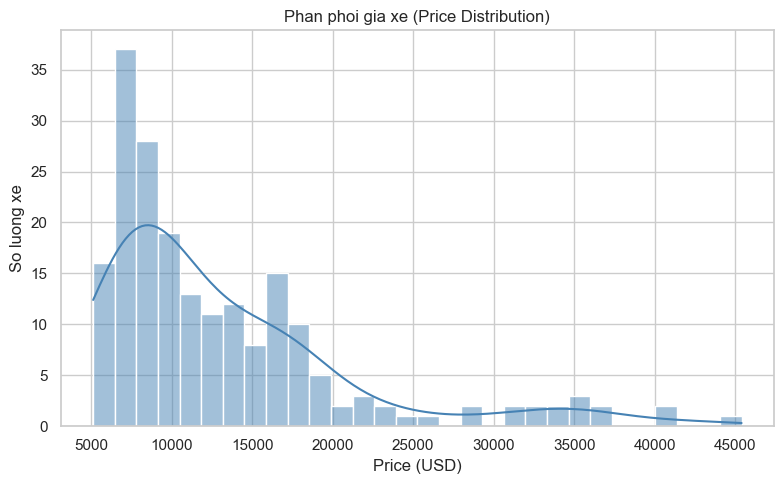

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(analysis_df["price"], bins=30, kde=True, color="steelblue")
plt.title('Phan phoi gia xe (Price Distribution)')
plt.xlabel('Price (USD)')
plt.ylabel('So luong xe')
plt.tight_layout()
plt.show()

- Phân bố lệch phải: đa số xe 5k-15k USD, mode ~8k. Giá trên 30k rất hiếm.
- Chỉ ~10% xe giá trên 25k - phân khúc xe sang.

## M2.2 Dataset có cân bằng theo body style không?

### M2.2 Cân bằng theo body_style?
**Biểu đồ:** Countplot của `body_style`.

C:\Users\PC\AppData\Local\Temp\ipykernel_25112\4251204803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=analysis_df, x="body_style",


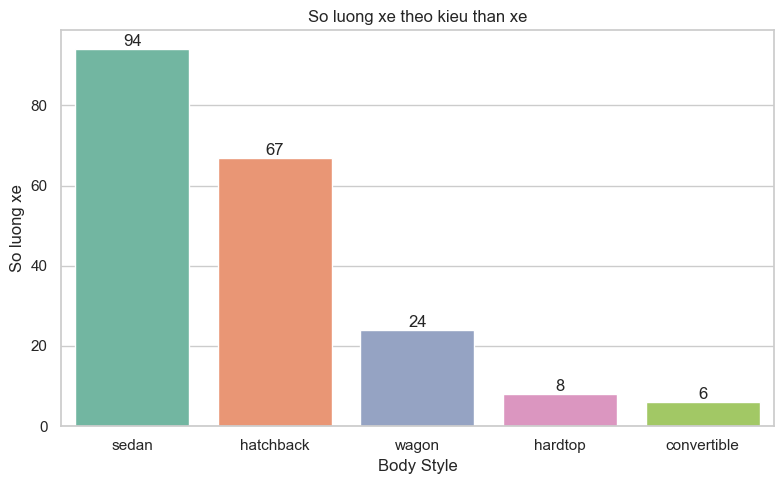

In [21]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=analysis_df, x="body_style",
                  order=analysis_df["body_style"].value_counts().index,
                  palette="Set2")
plt.title('So luong xe theo kieu than xe')
plt.xlabel('Body Style')
plt.ylabel('So luong xe')
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.show()

- Không cân bằng: `sedan` ~96 xe, `hatchback` ~70, `wagon` ~25. `convertible`/`hardtop` chỉ ~9 xe.
- Phân tích trên convertible/hardtop không đáng tin cậy vì sample size nhỏ.

## M2.3 Price khác nhau theo body style ra sao?

### M2.3 Price theo body_style
**Biểu đồ:** Boxplot price theo `body_style`.

C:\Users\PC\AppData\Local\Temp\ipykernel_25112\1738513698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="body_style", y="price", palette="Set2")


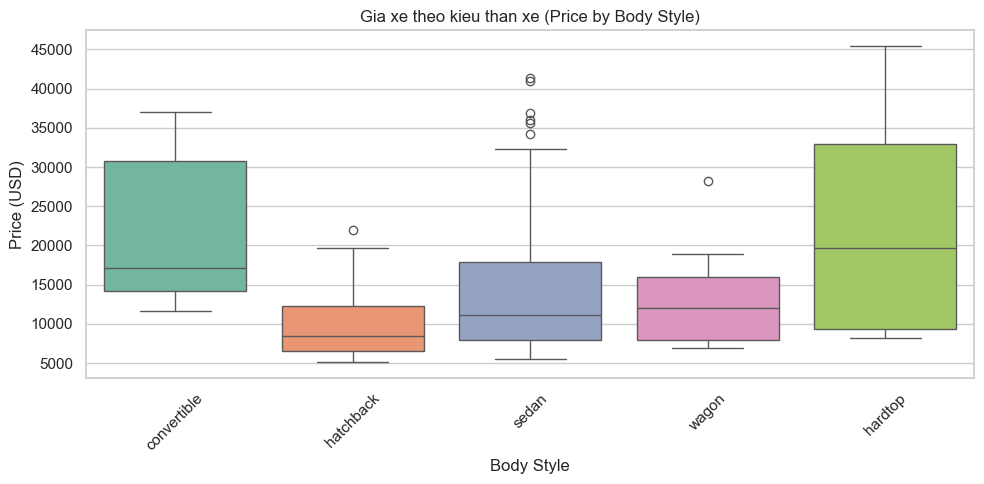

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=analysis_df, x="body_style", y="price", palette="Set2")
plt.title('Gia xe theo kieu than xe (Price by Body Style)')
plt.xlabel('Body Style')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- `hardtop`/`convertible` median cao nhất (~22k-30k) - phân khúc thể thao.
- `hatchback` median thấp nhất (~6k-7k) - phân khúc phổ thông.
- `sedan` phạm vi rộng nhất (~5k-38k), bao gồm nhiều phân khúc.

## M2.4 Engine size liên quan thế nào tới price?

### M2.4 Engine size vs Price
**Biểu đồ:** Scatter engine_size vs price, hue=fuel_type.

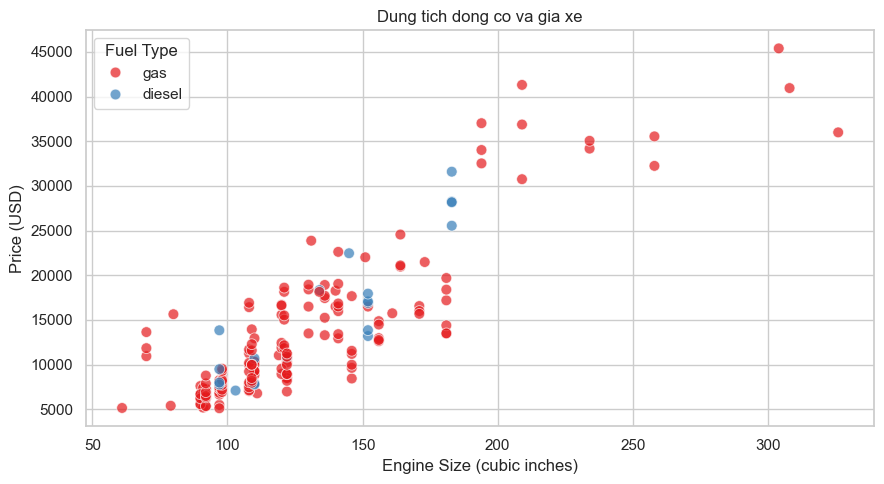

In [23]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=analysis_df, x="engine_size", y="price", hue="fuel_type",
               palette="Set1", alpha=0.7, s=60)
plt.title('Dung tich dong co va gia xe')
plt.xlabel('Engine Size (cubic inches)')
plt.ylabel('Price (USD)')
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

- Engine size càng lớn thì price càng cao - rõ dưới 200 ci.
- Xe gas chiếm đa số, diesel tập trung ở engine_size nhỏ-trung bình với giá thấp-trung bình.
- Xe gas >200 ci (Mercedes, BMW) có giá rất cao - phân khúc sang.

## M2.5 Các feature numeric tương quan ra sao?

### M2.5 Correlation heatmap
**Biểu đồ:** Heatmap 6 cột AUTO_FEATURES.

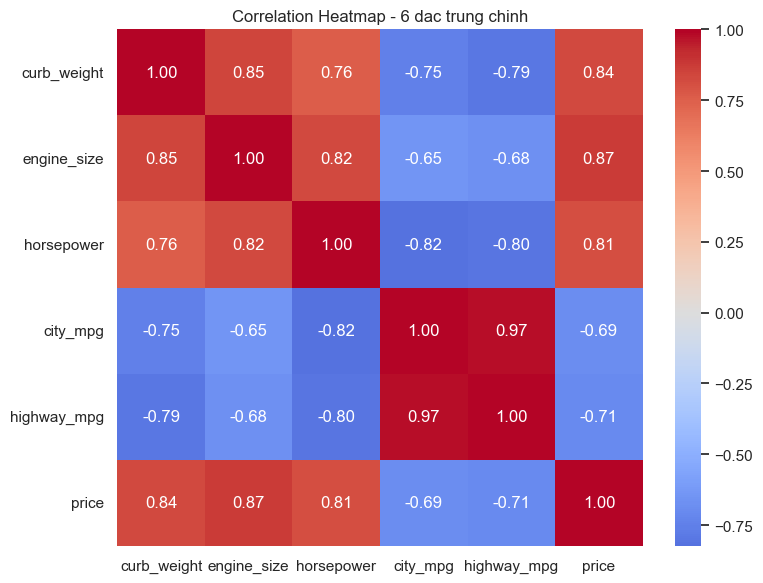

In [24]:
corr_matrix = np.corrcoef(X_auto.T)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=AUTO_FEATURES, yticklabels=AUTO_FEATURES, ax=ax)
plt.title('Correlation Heatmap - 6 dac trung chinh')
plt.tight_layout()
plt.show()

- `city_mpg` ~ `highway_mpg` (r~0.97): thông tin gần như trùng lặp.
- `engine_size` ~ `horsepower` (r~0.82) và ~ `curb_weight` (r~0.84).
- `price` tương quan dương với động cơ/trọng lượng/công suất, âm với mpg.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

### M2.6 Giá trung bình theo hãng xe
**Câu hỏi:** Hãng nào có giá trung bình cao nhất?

**Biểu đồ:** Horizontal bar chart (chỉ lấy hãng có >=3 mẫu).

C:\Users\PC\AppData\Local\Temp\ipykernel_25112\639407708.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=make_avg_price.values, y=make_avg_price.index, palette="viridis")


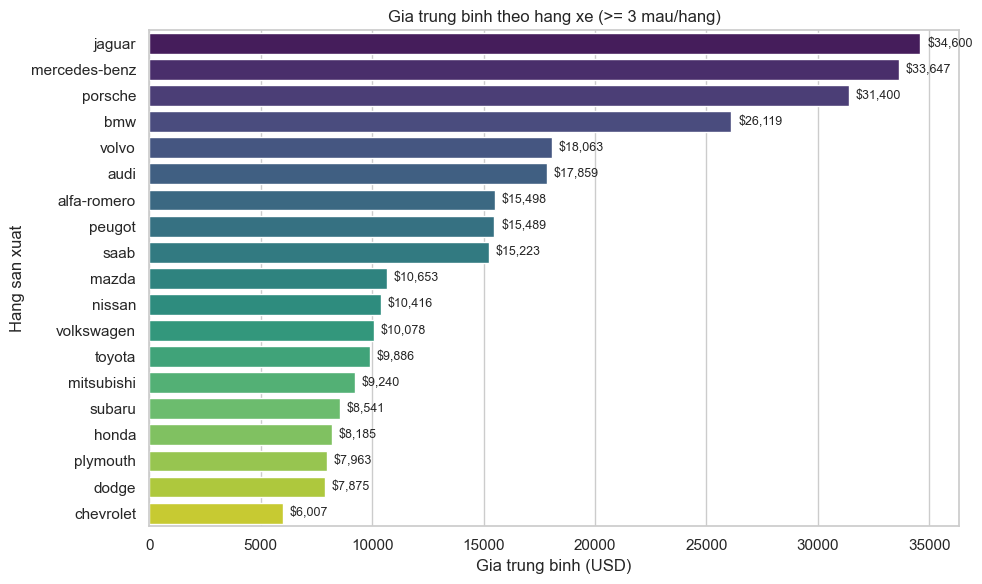

In [25]:
make_counts = analysis_df["make"].value_counts()
valid_makes = make_counts[make_counts >= 3].index
make_price_df = analysis_df[analysis_df["make"].isin(valid_makes)]
make_avg_price = make_price_df.groupby("make")["price"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=make_avg_price.values, y=make_avg_price.index, palette="viridis")
plt.title('Gia trung binh theo hang xe (>= 3 mau/hang)')
plt.xlabel('Gia trung binh (USD)')
plt.ylabel('Hang san xuat')
for i, v in enumerate(make_avg_price.values):
    ax.text(v + 300, i, f"${v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

- Jaguar đắt nhất (~35k USD), tiếp theo là Mercedes-Benz đắt nhì (~32k USD), tiếp BMW (~23k) và Volvo (~19k).
- Hãng Nhật (Honda ~6.5k, Toyota ~7.8k) rẻ hơn nhiều. Khoảng cách ~5 lần.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.
## Tổng hợp của sinh viên

Qua phân tích dataset Automobile 1985 (205 xe, 26 đặc trưng):

**1. Giá xe phân bố lệch phải:** Đa số xe 5k-15k USD, mode ~8k. Chỉ ~10% trên 25k. Outlier đều là xe hạng cao cấp.

**2. Kiểu thân xe ảnh hưởng rõ đến giá:** Hardtop/convertible median ~25k-30k, hatchback ~6k-7k. Sedan phạm vi 5k-38k.

**3. Engine size là yếu tố dự báo giá tốt nhất:** r ~ 0.76 với price. Cặp mpg tương quan gần như hoàn toàn (r~0.97).

**4. Hãng sản xuất phân tầng rõ ràng:** Châu Âu (Mercedes ~32k, BMW ~23k, Porsche ~33k) ở phân khúc cao cấp. Nhật Bản (Honda ~6.5k, Toyota ~7.8k) ở phân khúc phổ thông.

**5. 3 hạn chế chính:** (1) 59 missing values, tập trung ở normalized_losses (41 dòng). (2) Không cân bằng body_style: sedan ~50%, convertible/hardtop chỉ ~5%. (3) Dữ liệu 1985 - lỗi thời.

**Ví dụ correlation không nghĩa causation:** Engine size và price có r~0.76, nhưng không thể nói 'engine size lớn thì giá tăng'. Có thể do xe động cơ lớn thường kèm nhiều tiện ích khác hoặc thuộc hãng sang. Một xe Nhật 4 xi-lanh có thể đắt hơn xe Mỹ 8 xi-lanh công nghệ thấp.

**Câu hỏi phân tích tiếp:** Tại sao `num_cylinders` và `fuel_system` ảnh hưởng đến `city_mpg`/`highway_mpg`? Hiệu suất tuyệt đối giữa số xi-lanh và loại nhiên liệu như thế nào?